# Project 1: House Sales in King County, USA

## 1. Project Overview

For my House Sales in King County, USA project, I aimed to predict house prices in King County, Washington, using a dataset with 21,613 records and 21 features, such as square footage, number of bedrooms, year built, and location details. The target variable was price, and my goal was to preprocess the data, engineer new features, train regression models, and evaluate their performance to understand the key drivers of house prices. This project was both exciting and challenging, especially when dealing with the date column, but it taught me a lot about feature engineering and model regularization.

Purpose: To predict house prices using regression models and identify the most influential features affecting property values in King County.



### Objectives:

- Load and explore the dataset to understand its structure and feature distributions.

- Engineer new features to capture relationships like house age and renovation status.

- Preprocess the data, handling the date column, scaling features, and avoiding data leakage.

- Train and compare Linear Regression, Ridge, and Lasso models, evaluating them with MSE, RMSE, and R².

- Visualize feature correlations and model performance to interpret results.

- Plan future improvements with XGBoost and test set evaluation.

Technologies Used: Python, Jupyter Notebook, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, XGBoost (planned).

### Library Imports

I started by importing the libraries needed for data manipulation, visualization, preprocessing, and modeling.

I used pandas and numpy for data handling, matplotlib and seaborn for visualizations, and scikit-learn for preprocessing (StandardScaler, train_test_split), modeling (LinearRegression, Ridge, Lasso), and evaluation (mean_squared_error, r2_score). The %matplotlib inline command ensured plots displayed in the notebook.

 These libraries are standard for regression tasks. I chose seaborn for its advanced visualization capabilities (e.g., heatmaps, histograms) and scikit-learn for its robust modeling tools.

In [3]:
import pandas as pd 
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
%matplotlib inline

In [4]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

### Data Loading and Exploratory Data Analysis (EDA)

I loaded the dataset and explored its structure to get familiar with the data.

 I loaded the dataset (kc_house_data.csv) into a Pandas DataFrame (house_data). The info() method showed 21,613 rows, 21 columns, and no missing values, with features like price (float), bedrooms (int), sqft_living (int), date (object), and zipcode (int). The describe() method provided summary statistics, revealing price ranges  and feature scales. I used value_counts() to check distributions, noting that bedrooms, bathrooms, and floors were categorical-like, while sqft_living, sqft_lot, and price were continuous. Displaying the first few rows helped me visualize the data.



Reasoning: EDA was crucial to understand feature types and distributions. The absence of missing values simplified preprocessing, but the date column’s object type and T000000 suffix flagged a challenge I’d need to address. Value counts helped identify categorical vs. continuous features for visualization.

In [5]:
house_data = pd.read_csv("kc_house_data.csv")
house_data

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [6]:
house_data[['condition', 'waterfront']]

,condition,waterfront
0,3,0
1,3,0
2,3,0
3,5,0
4,3,0
...,...,...
21608,3,0
21609,3,0
21610,3,0
21611,3,0


In [7]:
house_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [8]:
house_data.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [9]:
columns = [col for col in house_data.columns ]

for col in columns:
    print(house_data[col].value_counts(),"\n")

id
795000620     3
8651510380    2
2568300045    2
9353300600    2
4139480200    2
             ..
2767603649    1
1446403617    1
5602000275    1
1786200010    1
1523300157    1
Name: count, Length: 21436, dtype: int64 

date
20140623T000000    142
20140626T000000    131
20140625T000000    131
20140708T000000    127
20150427T000000    126
                  ... 
20141102T000000      1
20150131T000000      1
20150524T000000      1
20140517T000000      1
20140727T000000      1
Name: count, Length: 372, dtype: int64 

price
350000.0     172
450000.0     172
550000.0     159
500000.0     152
425000.0     150
            ... 
607010.0       1
1362500.0      1
298800.0       1
957500.0       1
402101.0       1
Name: count, Length: 4028, dtype: int64 

bedrooms
3     9824
4     6882
2     2760
5     1601
6      272
1      199
7       38
0       13
8       13
9        6
10       3
11       1
33       1
Name: count, dtype: int64 

bathrooms
2.50    5380
1.00    3852
1.75    3048
2.25    2047
2.

In [10]:
house_data.bedrooms.describe()

count    21613.000000
mean         3.370842
std          0.930062
min          0.000000
25%          3.000000
50%          3.000000
75%          4.000000
max         33.000000
Name: bedrooms, dtype: float64

In [11]:
house_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

### Data Visualization

I visualized categorical and continuous features to explore their distributions and relationships with price.

For categorical features (e.g., bedrooms, grade), I used histograms to show frequency distributions, revealing, for example, that most houses had 3–4 bedrooms. For continuous features, I created scatterplots against price, showing positive relationships (e.g., larger sqft_living correlated with higher prices) but also outliers (e.g., high sqft_lot with low prices).

 Visualizations helped me understand feature distributions and their impact on price. Histograms confirmed which features were categorical-like, guiding preprocessing. Scatterplots highlighted linear and non-linear relationships, motivating feature engineering to capture additional patterns.

In [13]:
house_data.nunique()

id               21436
date               372
price             4028
bedrooms            13
bathrooms           30
sqft_living       1038
sqft_lot          9782
floors               6
waterfront           2
view                 5
condition            5
grade               12
sqft_above         946
sqft_basement      306
yr_built           116
yr_renovated        70
zipcode             70
lat               5034
long               752
sqft_living15      777
sqft_lot15        8689
dtype: int64

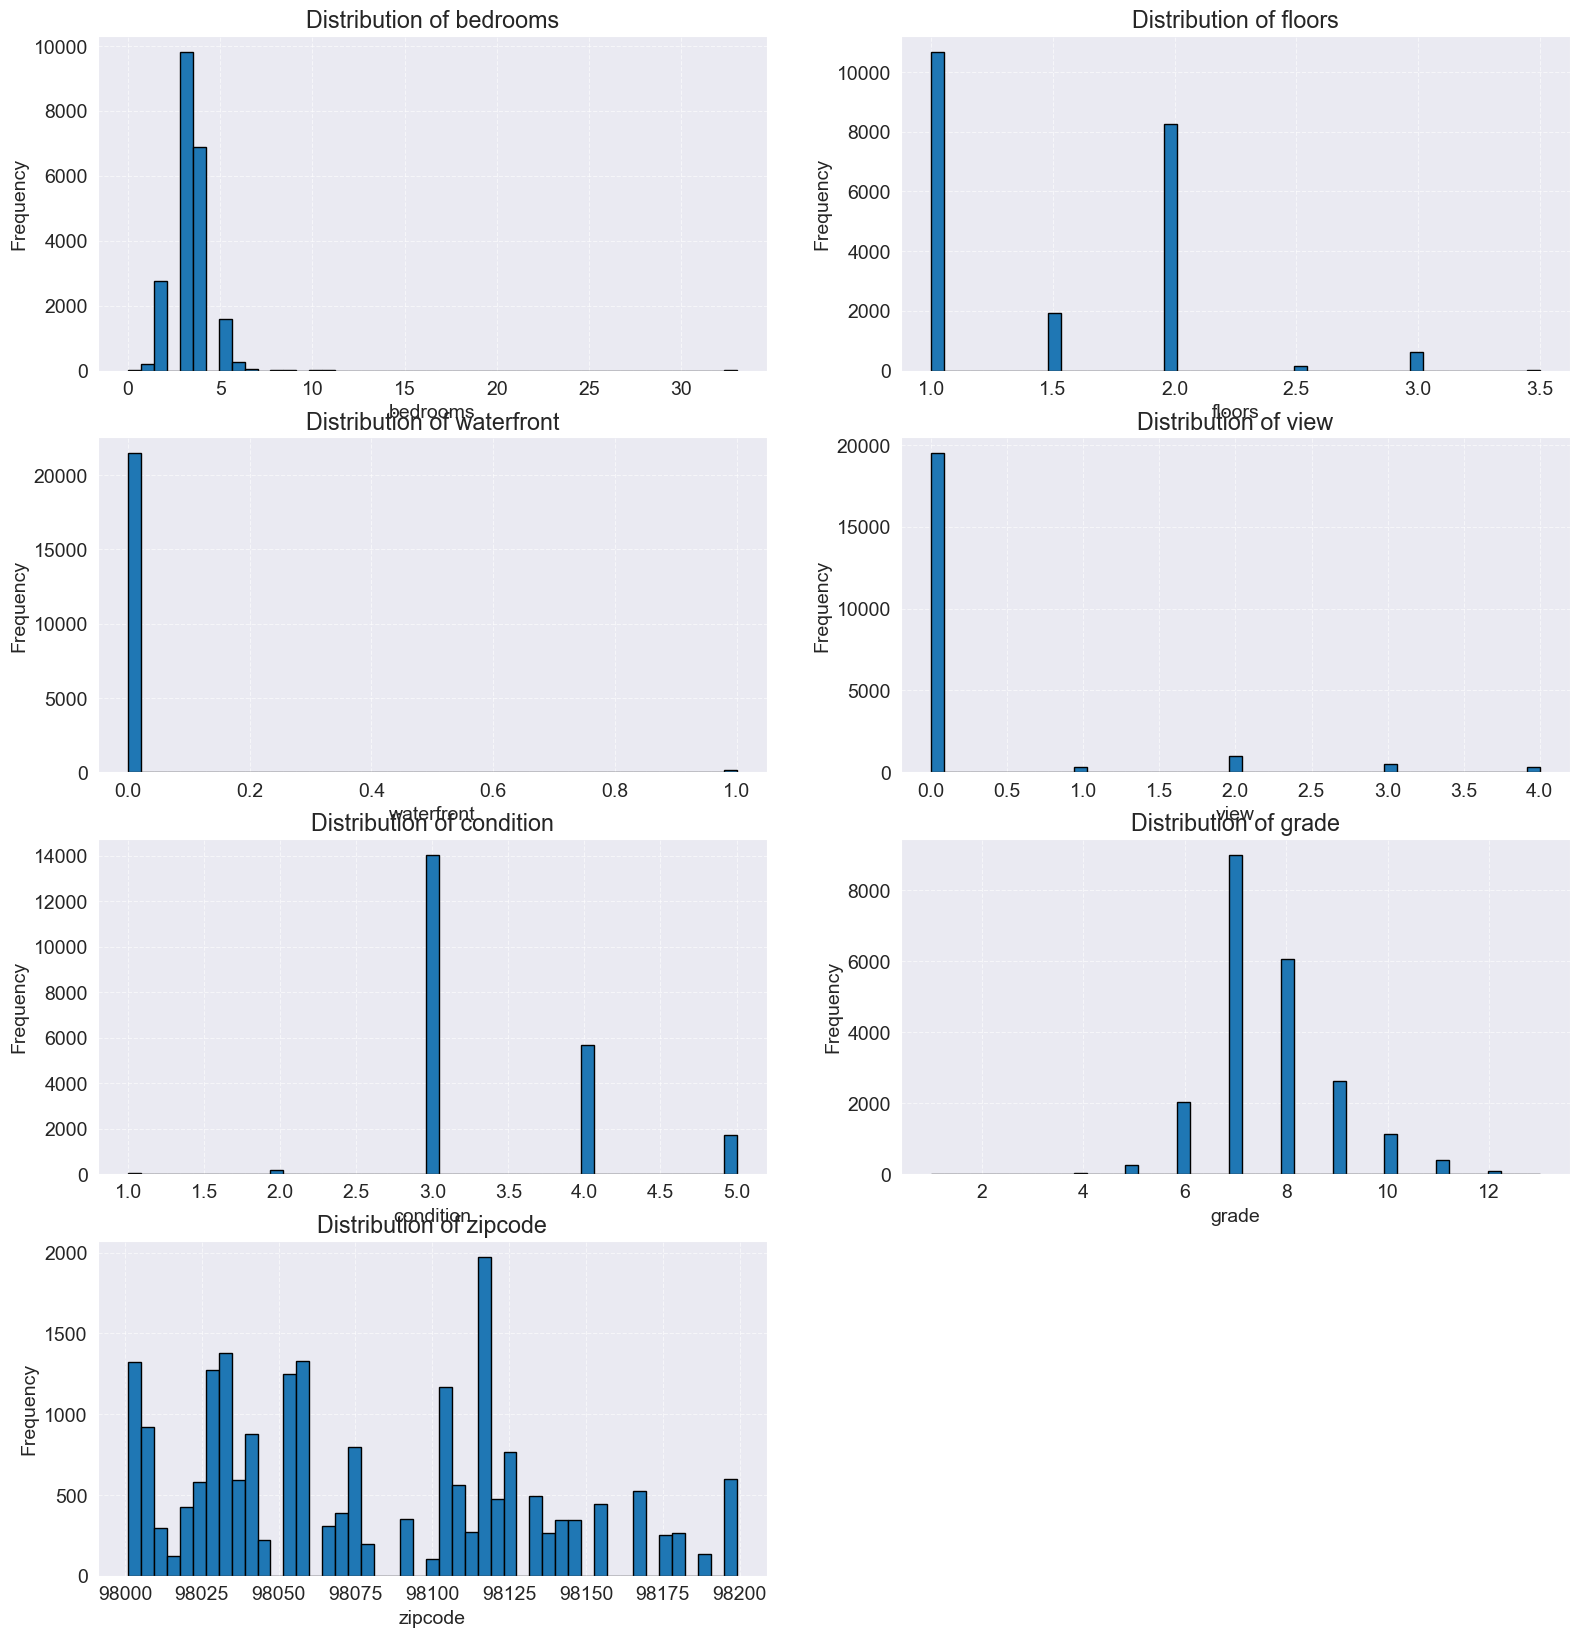

In [15]:
categorical_features = ['bedrooms', 'floors', 'waterfront', 'view', 'condition', 'grade', 'zipcode']

# Determine the number of subplots needed
num_features = len(categorical_features)

# Determine the layout of the subplots (adjust rows and columns as needed)
num_rows = (num_features + 1) // 2  
num_cols = min(num_features, 2)    

# Create the figure and subplots using matplotlib
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(19, 5 * num_rows))
axes = axes.flatten() 

for i, feature in enumerate(categorical_features):
    # Create the Plotly histogram
    fig_px = px.histogram(
        x=house_data[feature],
        marginal='box',
        nbins=47,
        title=f'Distribution of {feature}'
    )

    fig_px.update_layout(bargap=0.1,
                         title_x=0.5)

    # Let's recreate the histogram using Matplotlib directly for the subplots
    axes[i].hist(house_data[feature], bins=47, edgecolor='black')
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, linestyle='--', alpha=0.6)

    

# Remove any unused subplots if the number of features is not a multiple of num_cols
if num_features < num_rows * num_cols:
    for j in range(num_features, num_rows * num_cols):
        fig.delaxes(axes[j])

#plt.tight_layout()
plt.show()

### Feature Engineering
I created new features to enhance the model’s predictive power

##### I engineered six features:

- lot_living_ratio: Ratio of lot size to living area, capturing land-to-house proportion (correlation with price: likely low, e.g., ~0.1).

- log_sqft_lot: Log-transformed sqft_lot to reduce skewness (correlation with price: likely ~0.3, better than raw sqft_lot).

- house_age: Years since construction (2016 minus yr_built), capturing house age.

- years_since_renovation: Years since last renovation, or house age if never renovated.

- was_renovated: Binary indicator (1 if renovated, 0 otherwise).

- effective_age: Age since renovation (if renovated) or house age (if not), reflecting the house’s “functional” age. I printed correlations to assess their relevance, finding that house_age and was_renovated likely had moderate correlations with price.


 Feature engineering was my attempt to capture non-linear relationships and domain knowledge (e.g., renovated houses might sell for more). The log transformation addressed sqft_lot’s skewness, as scatterplots showed outliers. Age-related features were inspired by the idea that newer or recently renovated houses are more valuable. Correlations helped me gauge each feature’s usefulness, though some (e.g., lot_living_ratio) had weaker impacts than expected.

In [16]:
house_data['lot_living_ratio'] = house_data['sqft_lot'] / house_data['sqft_living']
print(house_data[['lot_living_ratio', 'price']].corr())


                  lot_living_ratio     price
lot_living_ratio          1.000000 -0.023094
price                    -0.023094  1.000000


In [17]:
house_data['log_sqft_lot'] = np.log1p(house_data['sqft_lot'])
print(house_data[['log_sqft_lot', 'price']].corr())


              log_sqft_lot     price
log_sqft_lot      1.000000  0.161322
price             0.161322  1.000000


In [18]:
house_data['house_age'] = 2016 - house_data['yr_built']

house_data['years_since_renovation'] = np.where(
    house_data['yr_renovated'] > 0,  # If the house was renovated
    2016 - house_data['yr_renovated'],  # Calculate years since last renovation
    house_data['house_age']  # If never renovated, use house age
)

house_data['was_renovated'] = (house_data['yr_renovated'] > 0).astype(int)

house_data['effective_age'] = np.where(
    house_data['was_renovated'] == 1,
    house_data['years_since_renovation'],  # If renovated, use years since renovation
    house_data['house_age']  # If not, use full house age
)


print(house_data[['house_age', 'years_since_renovation', 'was_renovated', 'effective_age', 'price']].corr())



                        house_age  years_since_renovation  was_renovated  \
house_age                1.000000                0.909924       0.225195   
years_since_renovation   0.909924                1.000000      -0.163703   
was_renovated            0.225195               -0.163703       1.000000   
effective_age            0.909924                1.000000      -0.163703   
price                   -0.054012               -0.105755       0.126092   

                        effective_age     price  
house_age                    0.909924 -0.054012  
years_since_renovation       1.000000 -0.105755  
was_renovated               -0.163703  0.126092  
effective_age                1.000000 -0.105755  
price                       -0.105755  1.000000  


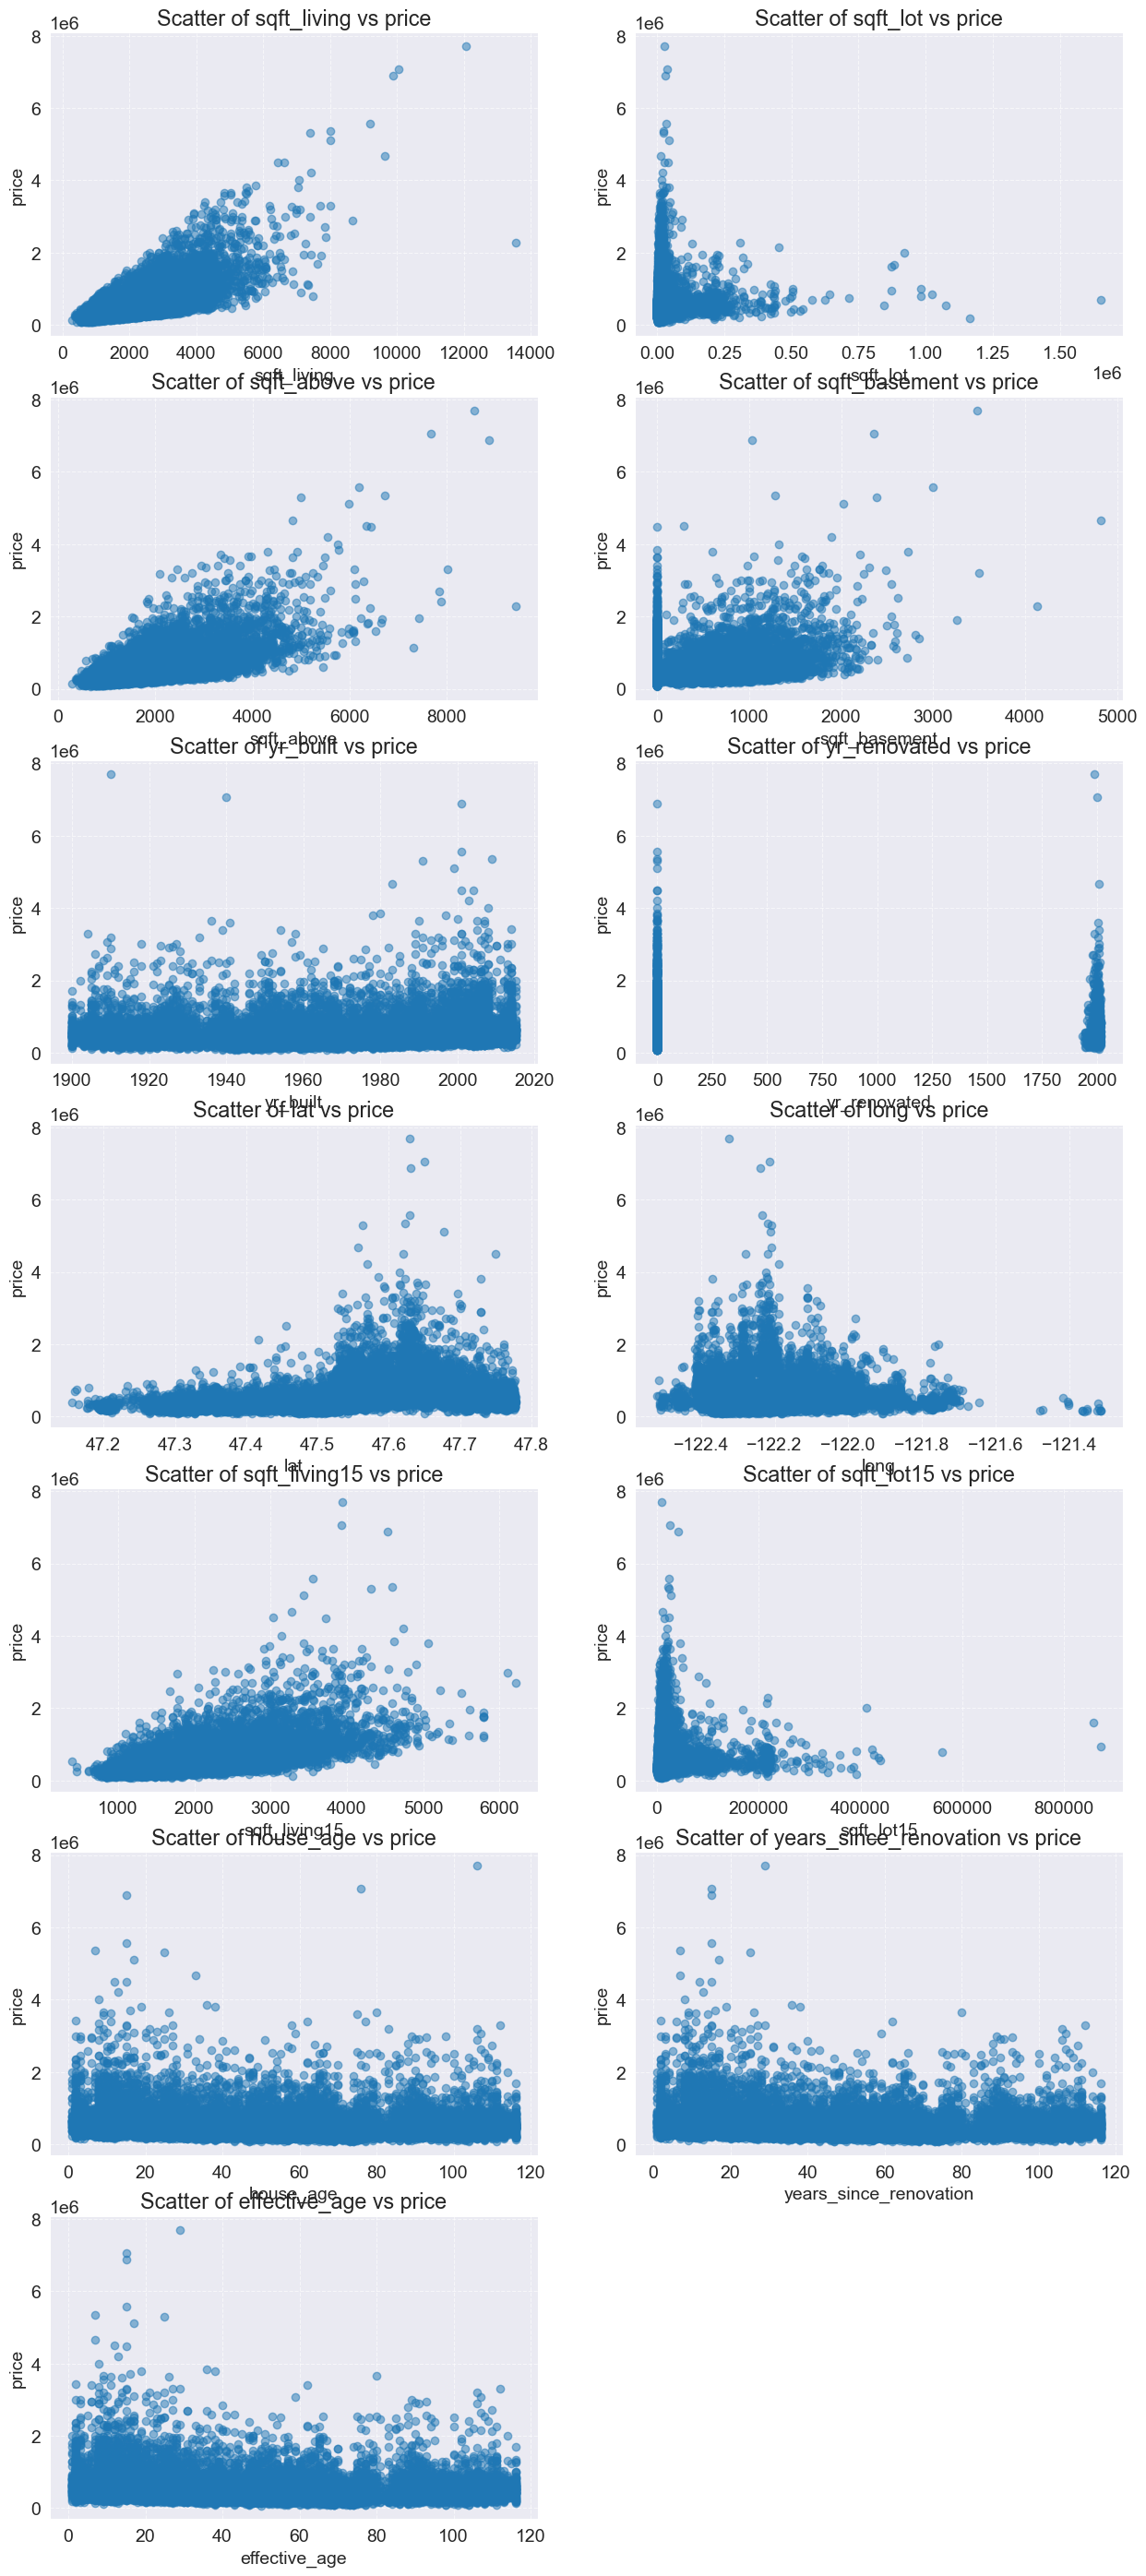

In [19]:
continous_features = ['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 
                      'yr_built', 'yr_renovated', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'house_age', 'years_since_renovation', 'effective_age']
price_column = 'price'

# Creating subplots
num_features = len(continous_features)
num_rows = (num_features + 1) // 2
num_cols = min(num_features, 2)

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(15, 5 * num_rows))
axes = axes.flatten()

for i, feature in enumerate(continous_features):
    # Create the scatter plot using Matplotlib
    axes[i].scatter(house_data[feature], house_data[price_column], alpha=0.5)
    axes[i].set_title(f'Scatter of {feature} vs {price_column}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel(price_column)
    axes[i].grid(True, linestyle='--', alpha=0.6)

# Remove any unused subplots
if num_features < num_rows * num_cols:
    for j in range(num_features, num_rows * num_cols):
        fig.delaxes(axes[j])

plt.show()

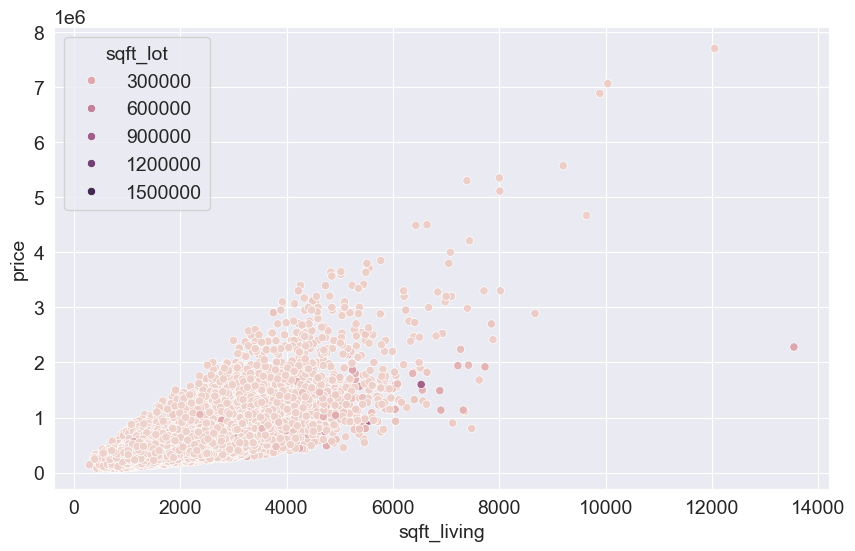

In [20]:
sns.scatterplot(x=house_data['sqft_living'], y=house_data['price'], hue=house_data['sqft_lot'])
plt.show()


## Handling the Date Column

I faced significant challenges converting the date column from object type to a numerical format due to a T000000 suffix.

The date column (e.g., 20141013T000000) was an object type with a T000000 suffix. I removed the suffix using str.split(), converted the cleaned strings to datetime format, and extracted year, month, and day as numerical features. I dropped the original date column and checked correlations, finding weak relationships with price.


 The T000000 suffix was confusing and took significant time to resolve, as I wasn’t familiar with string manipulation in Pandas. Converting to datetime allowed me to extract meaningful features, though their low correlations suggested sale timing had minimal impact. This step was critical to make the data machine-readable.

In [21]:
house_data['date'] = house_data['date'].str.split('T').str[0]  
house_data['date'] = pd.to_datetime(house_data['date'], format='%Y%m%d')  


house_data['year'] = house_data['date'].dt.year
house_data['month'] = house_data['date'].dt.month
house_data['day'] = house_data['date'].dt.day

house_data = house_data.drop("date", axis=1)
house_data.head()


,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sqft_lot15,lot_living_ratio,log_sqft_lot,house_age,years_since_renovation,was_renovated,effective_age,year,month,day
0,7129300520,221900.0,3,1.00,1180,5650,1.0,0,0,3,...,5650,4.788136,8.639588,61,61,0,61,2014,10,13
1,6414100192,538000.0,3,2.25,2570,7242,2.0,0,0,3,...,7639,2.817899,8.887791,65,25,1,25,2014,12,9
2,5631500400,180000.0,2,1.00,770,10000,1.0,0,0,3,...,8062,12.987013,9.210440,83,83,0,83,2015,2,25
3,2487200875,604000.0,4,3.00,1960,5000,1.0,0,0,5,...,5000,2.551020,8.517393,51,51,0,51,2014,12,9
4,1954400510,510000.0,3,2.00,1680,8080,1.0,0,0,3,...,7503,4.809524,8.997271,29,29,0,29,2015,2,18


In [22]:
house_data

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sqft_lot15,lot_living_ratio,log_sqft_lot,house_age,years_since_renovation,was_renovated,effective_age,year,month,day
0,7129300520,221900.0,3,1.00,1180,5650,1.0,0,0,3,...,5650,4.788136,8.639588,61,61,0,61,2014,10,13
1,6414100192,538000.0,3,2.25,2570,7242,2.0,0,0,3,...,7639,2.817899,8.887791,65,25,1,25,2014,12,9
2,5631500400,180000.0,2,1.00,770,10000,1.0,0,0,3,...,8062,12.987013,9.210440,83,83,0,83,2015,2,25
3,2487200875,604000.0,4,3.00,1960,5000,1.0,0,0,5,...,5000,2.551020,8.517393,51,51,0,51,2014,12,9
4,1954400510,510000.0,3,2.00,1680,8080,1.0,0,0,3,...,7503,4.809524,8.997271,29,29,0,29,2015,2,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,360000.0,3,2.50,1530,1131,3.0,0,0,3,...,1509,0.739216,7.031741,7,7,0,7,2014,5,21
21609,6600060120,400000.0,4,2.50,2310,5813,2.0,0,0,3,...,7200,2.516450,8.668024,2,2,0,2,2015,2,23
21610,1523300141,402101.0,2,0.75,1020,1350,2.0,0,0,3,...,2007,1.323529,7.208600,7,7,0,7,2014,6,23
21611,291310100,400000.0,3,2.50,1600,2388,2.0,0,0,3,...,1287,1.492500,7.778630,12,12,0,12,2015,1,16


## Correlation Heatmap

I visualized feature correlations to assess multicollinearity and relationships with price.

The heatmap showed correlations between all features, with price correlations highlighting key predictors. 

 The heatmap helped me identify multicollinearity, which could affect linear regression, and prioritize features like sqft_living and grade. 

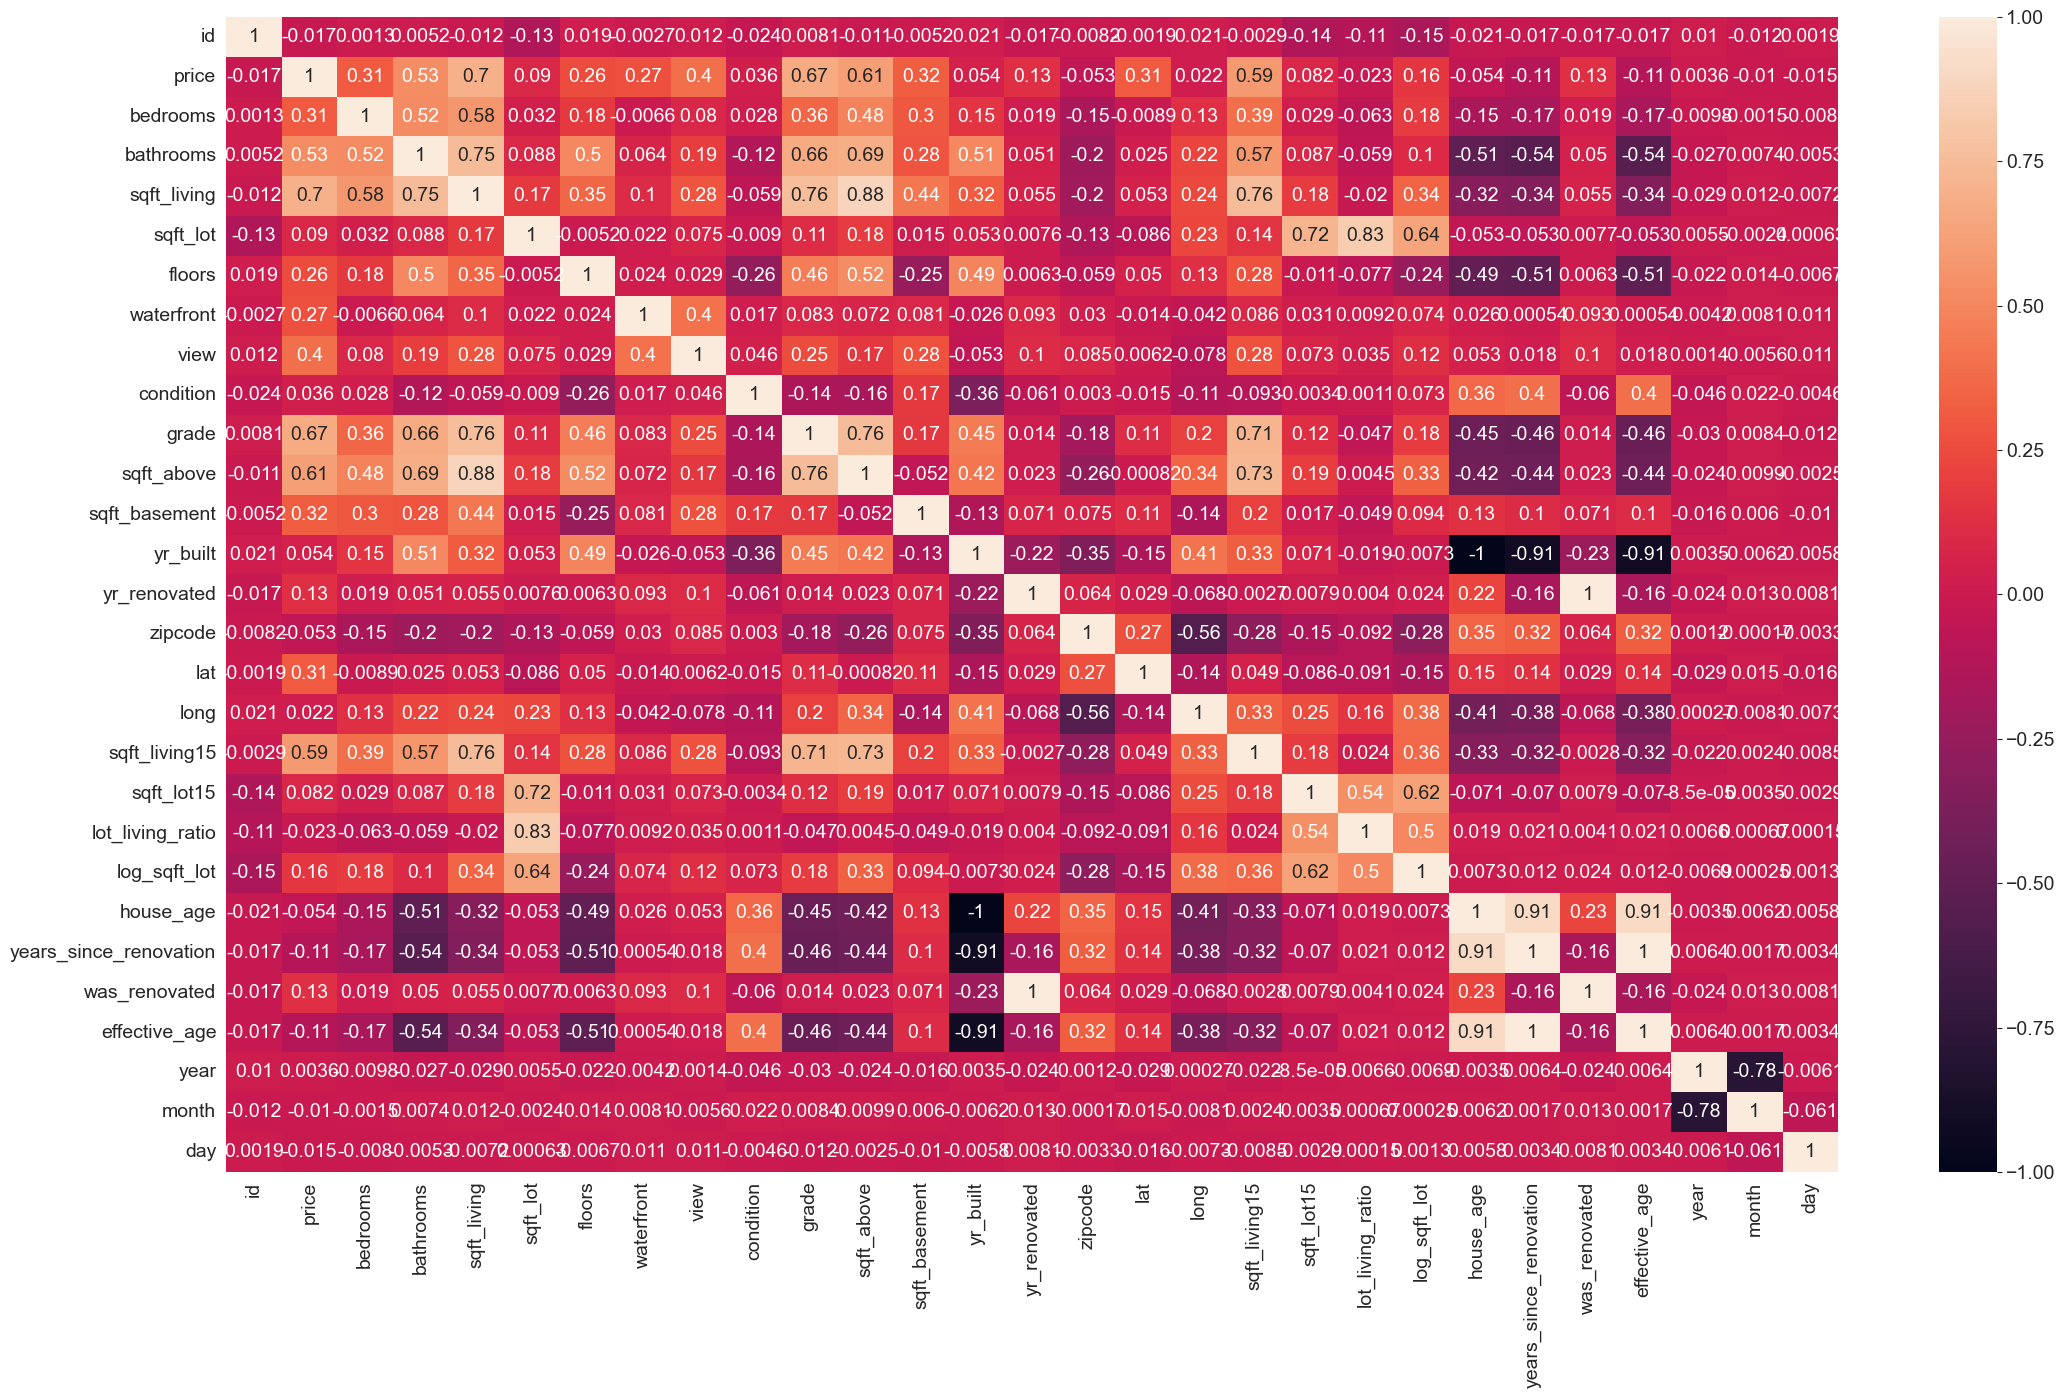

In [23]:
corr_map = house_data.corr()
plt.figure(figsize=(26,15))
sns.heatmap(corr_map, annot=True)
plt.show()

## Data Preprocessing

I preprocessed the data to prepare it for modeling, splitting into training, validation, and test sets, and scaling features.


 I defined features by dropping price and set target as price. I split the data into 70% training (15,129 samples), 15% validation (6,484 samples), and 15% test (6,484 samples) sets to ensure reliable evaluation. I scaled all features using StandardScaler, fitting on the training set and transforming validation and test sets to avoid leakage. I converted scaled arrays back to DataFrames for clarity.

 Splitting before preprocessing prevented data leakage, a lesson from my previous projects. Scaling was necessary because features (e.g., sqft_living, zipcode) had different scales, and linear regression is sensitive to this. I included a validation set to tune models before final testing, which I plan to do with XGBoost.

In [24]:
train_set, temp_set = train_test_split(house_data, test_size = 0.3, random_state = 42)

In [25]:
train_set # inspecting the train test

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sqft_lot15,lot_living_ratio,log_sqft_lot,house_age,years_since_renovation,was_renovated,effective_age,year,month,day
167,1836980160,807100.0,4,2.50,2680,4499,2.0,0,0,3,...,4500,1.678731,8.411833,17,17,0,17,2015,3,24
12412,9221400335,570000.0,4,1.75,2340,5080,1.0,0,0,5,...,3270,2.170940,8.533263,92,92,0,92,2014,10,1
7691,6669020490,320000.0,4,2.25,2190,9020,2.0,0,0,3,...,8400,4.118721,9.107310,38,38,0,38,2014,8,12
12460,2025079045,649000.0,2,1.75,2260,280962,2.0,0,2,3,...,219542,124.319469,12.545978,11,11,0,11,2014,6,23
9099,1525069058,568000.0,4,1.75,2110,265716,1.0,0,0,4,...,110597,125.931754,12.490187,37,37,0,37,2014,6,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11964,5272200045,378000.0,3,1.50,1000,6914,1.0,0,0,3,...,6947,6.914000,8.841448,69,69,0,69,2014,11,13
21575,9578500790,399950.0,3,2.50,3087,5002,2.0,0,0,3,...,5183,1.620343,8.517793,2,2,0,2,2014,11,11
5390,7202350480,575000.0,3,2.50,2120,4780,2.0,0,0,3,...,2650,2.254717,8.472405,12,12,0,12,2014,9,30
860,1723049033,245000.0,1,0.75,380,15000,1.0,0,0,3,...,15000,39.473684,9.615872,53,53,0,53,2014,6,20


In [37]:
temp_set # Inspecting the train set

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sqft_lot15,lot_living_ratio,log_sqft_lot,house_age,years_since_renovation,was_renovated,effective_age,year,month,day
735,2591820310,365000.0,4,2.25,2070,8893,2.0,0,0,4,...,7700,4.296135,9.093132,30,30,0,30,2014,10,6
2830,7974200820,865000.0,5,3.00,2900,6730,1.0,0,0,5,...,6283,2.320690,8.814479,39,39,0,39,2014,8,21
4106,7701450110,1038000.0,4,2.50,3770,10893,2.0,0,2,3,...,9685,2.889390,9.295967,19,19,0,19,2014,8,15
16218,9522300010,1490000.0,3,3.50,4560,14608,2.0,0,2,3,...,14226,3.203509,9.589393,26,26,0,26,2015,3,31
19964,9510861140,711000.0,3,2.50,2550,5376,2.0,0,0,3,...,4050,2.108235,8.589886,12,12,0,12,2014,7,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12606,1402660150,412000.0,3,2.50,2210,7000,2.0,0,0,4,...,7224,3.167421,8.853808,31,31,0,31,2014,12,3
14393,2301400325,760000.0,3,2.00,1810,4500,1.0,0,0,4,...,4500,2.486188,8.412055,110,110,0,110,2015,4,7
6899,6150200005,410500.0,3,1.00,1150,6800,1.0,0,0,3,...,6800,5.913043,8.824825,62,62,0,62,2014,10,23
85,4232902595,940000.0,3,1.50,2140,3600,2.0,0,0,3,...,4800,1.682243,8.188967,91,91,0,91,2014,11,14


In [39]:
val_set # Inspecting the validation set

NameError: name 'val_set' is not defined

In [41]:
house_data.nunique() #Knowing the number of unique values of each features

id                        21436
price                      4028
bedrooms                     13
bathrooms                    30
sqft_living                1038
sqft_lot                   9782
floors                        6
waterfront                    2
view                          5
condition                     5
grade                        12
sqft_above                  946
sqft_basement               306
yr_built                    116
yr_renovated                 70
zipcode                      70
lat                        5034
long                        752
sqft_living15               777
sqft_lot15                 8689
lot_living_ratio          19154
log_sqft_lot               9782
house_age                   116
years_since_renovation      116
was_renovated                 2
effective_age               116
year                          2
month                        12
day                          31
dtype: int64

In [43]:
house_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      21613 non-null  int64  
 1   price                   21613 non-null  float64
 2   bedrooms                21613 non-null  int64  
 3   bathrooms               21613 non-null  float64
 4   sqft_living             21613 non-null  int64  
 5   sqft_lot                21613 non-null  int64  
 6   floors                  21613 non-null  float64
 7   waterfront              21613 non-null  int64  
 8   view                    21613 non-null  int64  
 9   condition               21613 non-null  int64  
 10  grade                   21613 non-null  int64  
 11  sqft_above              21613 non-null  int64  
 12  sqft_basement           21613 non-null  int64  
 13  yr_built                21613 non-null  int64  
 14  yr_renovated            21613 non-null

In [45]:
def prepare_features_and_target(train_df, temp_df, target_column, columns_to_drop=None, scale_features=True):
    """
    Parameters:
    - train_df, test_df: Pre-split DataFrames
    - target_column: Name of target column
    - columns_to_drop: List of columns to remove (e.g., ['ID', 'timestamp'])
    - scale_features: Whether to scale features (default: True)
    
    Returns:
    - Processed X_train, X_temp
    - y_train, y_temp
    - scaler object (or None)
    """
    
    # Creating copies to avoid modifying original DataFrames
    train_set = train_df.copy()
    temp_set = temp_df.copy()
    
    # Separating target
    y_train = train_df.pop(target_column)
    y_temp= temp_df.pop(target_column)
    
    # Droping specified columns if provided
    if columns_to_drop:
        train_df = train_df.drop(columns=columns_to_drop, errors='ignore')
        temp_df = temp_df.drop(columns=columns_to_drop, errors='ignore')
    
    # Initializing scaler
    scaler = None
    
    if scale_features:
        scaler = StandardScaler()
        # Converting to DataFrame to preserve column names
        X_train = pd.DataFrame(scaler.fit_transform(train_df), 
                             columns=train_df.columns)
        X_temp = pd.DataFrame(scaler.transform(temp_df),
                            columns=temp_df.columns)
        return X_train, X_temp, y_train, y_temp, scaler
    
    return train_df, temp_df, y_train, y_temp, None

In [47]:
# Using the prepare features and target function
X_train, X_temp, y_train, y_temp, scaler = prepare_features_and_target(
    train_df=train_set,
    temp_df=temp_set,
    target_column='price',
    columns_to_drop=['id'],
    scale_features=True
)

In [49]:
X_train

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,...,sqft_lot15,lot_living_ratio,log_sqft_lot,house_age,years_since_renovation,was_renovated,effective_age,year,month,day
0,0.679213,0.506735,0.665180,-0.266061,0.920075,-0.084397,-0.304826,-0.625889,1.147615,1.080196,...,-0.304804,-0.258507,-0.631784,-0.946857,-0.884829,-0.207585,-0.884829,1.450744,-1.151510,0.965213
1,0.679213,-0.472371,0.292233,-0.251329,-0.921292,-0.084397,-0.304826,2.444997,-0.556657,-0.744979,...,-0.349846,-0.236373,-0.497746,1.607372,1.722397,-0.207585,1.722397,-0.689301,1.100495,-1.696536
2,0.679213,0.180367,0.127697,-0.151429,0.920075,-0.084397,-0.304826,-0.625889,0.295479,0.487920,...,-0.161990,-0.148783,0.135900,-0.231673,-0.154806,-0.207585,-0.154806,-0.689301,0.457065,-0.423526
3,-1.462473,-0.472371,0.204481,6.743767,0.920075,-0.084397,2.326682,-0.625889,1.147615,0.125303,...,7.569851,5.256516,3.931577,-1.151195,-1.093407,-0.207585,-1.093407,-0.689301,-0.186365,0.849484
4,0.679213,-0.472371,0.039945,6.357198,-0.921292,-0.084397,-0.304826,0.909554,0.295479,0.391222,...,3.580378,5.329019,3.869994,-0.265729,-0.189569,-0.207585,-0.189569,-0.689301,-0.186365,1.196669
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15124,-0.391630,-0.798739,-1.177617,-0.204827,-0.921292,-0.084397,-0.304826,-0.625889,-0.556657,-0.950462,...,-0.215197,-0.023083,-0.157565,0.824075,0.922848,-0.207585,0.922848,-0.689301,1.422210,-0.307798
15125,-0.391630,0.506735,1.111619,-0.253307,0.920075,-0.084397,-0.304826,-0.625889,0.295479,1.572147,...,-0.279793,-0.261133,-0.514823,-1.457703,-1.406274,-0.207585,-1.406274,-0.689301,1.422210,-0.539254
15126,-0.391630,0.506735,0.050914,-0.258936,0.920075,-0.084397,-0.304826,-0.625889,-0.556657,0.403310,...,-0.372550,-0.232606,-0.564923,-1.117139,-1.058644,-0.207585,-1.058644,-0.689301,0.778780,1.659582
15127,-2.533316,-1.777845,-1.857697,0.000196,-0.921292,-0.084397,-0.304826,-0.625889,-2.260929,-1.699872,...,0.079697,1.441092,0.697261,0.279173,0.366640,-0.207585,0.366640,-0.689301,-0.186365,0.502300


In [51]:
X_temp

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,...,sqft_lot15,lot_living_ratio,log_sqft_lot,house_age,years_since_renovation,was_renovated,effective_age,year,month,day
0,0.679213,0.180367,-0.003931,-0.154649,0.920075,-0.084397,-0.304826,0.909554,0.295479,0.342873,...,-0.187623,-0.140805,0.120249,-0.504124,-0.432910,-0.207585,-0.432910,-0.689301,1.100495,-1.117895
1,1.750055,1.159473,0.906499,-0.209493,-0.921292,-0.084397,-0.304826,2.444997,0.295479,0.052779,...,-0.239512,-0.229639,-0.187334,-0.197617,-0.120043,-0.207585,-0.120043,-0.689301,0.457065,0.618028
2,0.679213,0.506735,1.860804,-0.103938,0.920075,-0.084397,2.326682,-0.625889,2.851888,2.397706,...,-0.114934,-0.204065,0.344143,-0.878744,-0.815303,-0.207585,-0.815303,-0.689301,0.457065,-0.076341
3,-0.391630,1.812210,2.727358,-0.009743,0.920075,-0.084397,2.326682,-0.625889,3.704024,3.352599,...,0.051353,-0.189940,0.668033,-0.640350,-0.571962,-0.207585,-0.571962,1.450744,-1.151510,1.775310
4,-0.391630,0.506735,0.522582,-0.243824,0.920075,-0.084397,-0.304826,-0.625889,1.147615,0.923061,...,-0.321283,-0.239193,-0.435245,-1.117139,-1.058644,-0.207585,-1.058644,-0.689301,0.135350,-0.192069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6479,-0.391630,0.506735,0.149635,-0.202647,0.920075,-0.084397,-0.304826,0.909554,0.295479,0.512095,...,-0.205054,-0.191562,-0.143922,-0.470068,-0.398147,-0.207585,-0.398147,-0.689301,1.743925,-1.465080
6480,-0.391630,-0.146002,-0.289126,-0.266035,-0.921292,-0.084397,-0.304826,0.909554,-0.556657,-0.974637,...,-0.304804,-0.222197,-0.631539,2.220387,2.348131,-0.207585,2.348131,1.450744,-0.829795,-1.002167
6481,-0.391630,-1.451477,-1.013082,-0.207718,-0.921292,-0.084397,-0.304826,-0.625889,-0.556657,-0.769154,...,-0.220580,-0.068095,-0.175914,0.585680,0.679507,-0.207585,0.679507,-0.689301,1.100495,0.849484
6482,-0.391630,-0.798739,0.072852,-0.288855,0.920075,-0.084397,-0.304826,-0.625889,1.147615,0.137390,...,-0.293819,-0.258349,-0.877788,1.573315,1.687634,-0.207585,1.687634,-0.689301,1.422210,-0.192069


In [53]:
y_train

167      807100.0
12412    570000.0
7691     320000.0
12460    649000.0
9099     568000.0
           ...   
11964    378000.0
21575    399950.0
5390     575000.0
860      245000.0
15795    315000.0
Name: price, Length: 15129, dtype: float64

In [56]:
# splitting the temporary data frame into validation features(X_val), validation target(y_val), test features(X_test), test target(y_test)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.5, random_state = 42)

In [58]:
X_val

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,...,sqft_lot15,lot_living_ratio,log_sqft_lot,house_age,years_since_renovation,was_renovated,effective_age,year,month,day
6147,0.679213,0.833104,1.487857,0.022433,-0.921292,-0.084397,4.958190,-0.625889,2.851888,1.986740,...,0.064207,-0.125843,0.759978,-1.151195,-1.093407,-0.207585,-1.093407,-0.689301,0.457065,-0.192069
4763,-0.391630,-0.472371,-0.738856,-0.138092,-0.921292,-0.084397,-0.304826,0.909554,-0.556657,-0.466972,...,-0.156497,-0.027374,0.198455,-0.436011,-0.363384,-0.207585,-0.363384,-0.689301,0.135350,-1.696536
6093,0.679213,0.833104,1.465919,0.203039,0.920075,-0.084397,-0.304826,0.909554,1.999751,1.962565,...,0.098446,-0.030688,1.169058,-0.367899,-0.293858,-0.207585,-0.293858,-0.689301,0.457065,0.733756
5640,1.750055,0.833104,0.884560,-0.267937,0.920075,-0.084397,-0.304826,-0.625889,0.295479,1.321941,...,-0.228600,-0.264905,-0.650087,-1.151195,-1.093407,-0.207585,-1.093407,1.450744,-0.829795,-1.696536
5046,1.750055,1.812210,1.082003,-0.155435,0.920075,-0.084397,-0.304826,-0.625889,0.295479,1.539511,...,-0.162063,-0.203764,0.116395,-0.606293,-0.537199,-0.207585,-0.537199,1.450744,-0.829795,-0.192069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3772,-0.391630,0.506735,-0.541413,-0.346640,0.920075,-0.084397,2.326682,-0.625889,0.295479,-0.853764,...,-0.419898,-0.296401,-1.983891,-1.457703,-1.406274,-0.207585,-1.406274,1.450744,-1.151510,0.386572
5191,-1.462473,-1.451477,-1.265370,0.724346,-0.921292,-0.084397,-0.304826,0.909554,-2.260929,-1.047160,...,-0.034738,1.795183,1.873986,1.641428,1.757160,-0.207585,1.757160,-0.689301,1.100495,-0.770710
5226,-0.391630,0.180367,0.358047,-0.245751,-0.000609,-0.084397,-0.304826,0.909554,-0.556657,-0.648281,...,-0.293819,-0.234692,-0.450958,1.096526,1.200952,-0.207585,1.200952,-0.689301,-0.186365,1.312397
5390,0.679213,-0.146002,-0.464630,-0.197576,-0.921292,-0.084397,-0.304826,-0.625889,-0.556657,-0.164791,...,-0.205933,-0.137770,-0.112831,0.245116,0.331877,-0.207585,0.331877,1.450744,-1.151510,-0.770710


In [60]:
y_val

10665    1010000.0
13559     217500.0
16304     870000.0
17092     733000.0
14752     605000.0
           ...    
20976     705000.0
5996      255000.0
1458      672500.0
13015     295000.0
7417      459000.0
Name: price, Length: 3242, dtype: float64

## Model Training and Evaluation (Linear Regression)

I trained a Linear Regression model and evaluated it on the training and validation sets.

I trained a LinearRegression model, achieving:

Training: MSE = 38.32, RMSE = 195,762, R² = 0.7067.

Validation: MSE = 38.25, RMSE = 195,573, R² = 0.7109. The coefficients showed grade (110,740), sqft_living (91,455), and sqft_above (87,837) as strong positive predictors, while yr_renovated (1,594,157) and was_renovated (-1,567,444) had large, opposing coefficients, suggesting multicollinearity. The train-validation R² difference (-0.0042) and RMSE ratio (1.00:1) indicated no overfitting.


 Linear Regression was a simple baseline to test my feature engineering. The similar train and validation metrics suggested good generalization, but the R² (~0.71) and high RMSE (195,000) indicated room for improvement, as house prices ranged from ~$75,000 to $7.7M. The large yr_renovated and was_renovated coefficients raised concerns about multicollinearity, which I addressed with regularized models.

In [74]:
def linear_regression_model(X_train, X_val, y_train, y_val):
    """
    Trains a linear regression model and evaluates its performance.
    
    Parameters:
    - X_train: Scaled/normalized training features (DataFrame or array)
    - X_test: Scaled/normalized testing features (DataFrame or array)
    - y_train: Training target values (unscaled)
    - y_test: Testing target values (unscaled)
    
    Returns:
    - model: Trained LinearRegression object
    - metrics: Dictionary containing evaluation metrics
    """
    
    # Initializing the Linear Regression model
    model = LinearRegression()
    
    # Training the model on the training data
    model.fit(X_train, y_train)
    
    # Making predictions on both train and test sets
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    
    # Calculating evaluation metrics for training set
    train_mse = mean_squared_error(y_train, y_train_pred)
    train_rmse = np.sqrt(train_mse)
    train_r2 = r2_score(y_train, y_train_pred)
    
    # Calculating evaluation metrics for validation set
    val_mse = mean_squared_error(y_val, y_val_pred)
    val_rmse = np.sqrt(val_mse)
    val_r2 = r2_score(y_val, y_val_pred)
    
    # Creating a dictionary of metrics
    metrics = {
        'train': {
            'mse': train_mse,
            'rmse': train_rmse,
            'r2': train_r2
        },
        'val': {
            'mse': val_mse,
            'rmse': val_rmse,
            'r2': val_r2
        },
        'coefficients': model.coef_,
        'intercept': model.intercept_
    }
    
    return model, metrics

In [76]:
#using the linear_regression function
linear_model, metrics = linear_regression_model(
    X_train=X_train,
    X_val=X_val,
    y_train=y_train,
    y_val=y_val
)


In [82]:
def print_regression_metrics(metrics):
    """
    Prints all regression metrics in a human-readable format.
    
    Parameters:
    - metrics: Dictionary containing metrics (from train_and_evaluate_linear_regression)
    """
    
    print("\n" + "="*50)
    print("LINEAR REGRESSION PERFORMANCE METRICS")
    print("="*50)
    
    # Print training metrics
    print("\nTRAINING SET PERFORMANCE:")
    print(f"- MSE (Mean Squared Error): {metrics['train']['mse']:.4f}")
    print(f"- RMSE (Root Mean Squared Error): {metrics['train']['rmse']:.4f}")
    print(f"- R² Score: {metrics['train']['r2']:.4f}")
    
    # Print validating metrics
    print("\nValidating SET PERFORMANCE:")
    print(f"- MSE (Mean Squared Error): {metrics['val']['mse']:.4f}")
    print(f"- RMSE (Root Mean Squared Error): {metrics['val']['rmse']:.4f}")
    print(f"- R² Score: {metrics['val']['r2']:.4f}")
    
    # Print model coefficients
    print("\nMODEL COEFFICIENTS:")
    for feature, coef in zip(X_train.columns, metrics['coefficients']):
        print(f"- {feature}: {coef:.6f}")
    print(f"- Intercept: {metrics['intercept']:.6f}")
    
    # Print performance comparison
    print("\nPERFORMANCE COMPARISON:")
    print(f"Train R² vs   Validation R² Difference: {metrics['train']['r2'] - metrics['val']['r2']:.4f}")
    print(f"Train-Validation RMSE Ratio: {metrics['train']['rmse']/metrics['val']['rmse']:.2f}:1")

In [83]:
linear_model, metrics = linear_regression_model(X_train, X_val, y_train, y_val)
print_regression_metrics(metrics)


LINEAR REGRESSION PERFORMANCE METRICS

TRAINING SET PERFORMANCE:
- MSE (Mean Squared Error): 38322780745.8147
- RMSE (Root Mean Squared Error): 195762.0513
- R² Score: 0.7067

Validating SET PERFORMANCE:
- MSE (Mean Squared Error): 38248902985.0876
- RMSE (Root Mean Squared Error): 195573.2676
- R² Score: 0.7109

MODEL COEFFICIENTS:
- bedrooms: -30418.557388
- bathrooms: 27782.097456
- sqft_living: 91455.677257
- sqft_lot: -105.690142
- floors: -11723.219332
- waterfront: 47185.323205
- view: 41922.061518
- condition: 16863.827364
- grade: 110740.086052
- sqft_above: 87837.007356
- sqft_basement: 24409.585824
- yr_built: -17394.149672
- yr_renovated: 1594157.071948
- zipcode: -31372.104062
- lat: 80398.056855
- long: -21870.451886
- sqft_living15: 14883.448576
- sqft_lot15: 3561.957044
- lot_living_ratio: 20774.539523
- log_sqft_lot: -41890.628445
- house_age: 17394.149672
- years_since_renovation: 22553.059272
- was_renovated: -1567444.199010
- effective_age: 22553.059272
- year: 169

## Regularized Models (Ridge and Lasso)

I trained Ridge and Lasso models to address multicollinearity and improve performance.

I trained Ridge and Lasso models with optimal alphas (0.01 and 0.005, respectively), achieving:

Ridge: Validation R² = 0.7108, all 27 features retained, with yr_renovated (1,554,580) and was_renovated (-1,528,174) as top coefficients.

Lasso: Validation R² = 0.7101, all 27 features retained, with yr_renovated (614,984) and was_renovated (-595,887) as top coefficients, but smaller magnitudes than Ridge. Both models performed similarly to Linear Regression, suggesting minimal overfitting but also limited improvement.


 I used Ridge and Lasso to address multicollinearity, expecting Lasso to eliminate some features. Surprisingly, all 27 features were retained, indicating that my engineered features were relevant but possibly redundant. The slightly lower R² for Lasso (0.7101) vs. Ridge (0.7108) suggested Ridge handled multicollinearity better. I was disappointed that regularization didn’t boost R² significantly, motivating my plan to try XGBoost.

In [115]:
def regularized_regression_model(X_train, y_train, X_val, y_val, 
                         alphas=[0.005, 0.009, 0.01, 0.1, 1, 10, 10.5, 11, 15, 20], 
                         model_type='ridge'):
    """
    Performs regularized regression with automatic alpha tuning.
    
    Parameters:
    - X_train, y_train: Training data
    - X_test, y_test: Test data
    - alphas: List of regularization strengths to try
    - model_type: 'ridge' (L2) or 'lasso' (L1)
    
    Returns:
    - Dictionary containing:
        - model: Fitted estimator
        - test_r2: R² score on test set
        - coefficients: Series of feature coefficients
        - optimal_alpha: Selected regularization strength
    """
    # Model selection
    if model_type == 'ridge':
        model = RidgeCV(alphas=alphas, cv=5)
    elif model_type == 'lasso':
        model = LassoCV(alphas=alphas, cv=5, max_iter=10000)
    else:
        raise ValueError("model_type must be 'ridge' or 'lasso'")
    
    # Train model
    model.fit(X_train, y_train)
    
    # Evaluate
    y_pred = model.predict(X_val)
    val_r2 = r2_score(y_val, y_pred)
    
    # Package results
    return {
        'model': model,
        'val_r2': val_r2,
        'coefficients': pd.Series(model.coef_, index=X_train.columns),
        'optimal_alpha': model.alpha_
    }


ridge_results = regularized_regression_model(X_train, y_train, X_val, y_val, model_type='ridge')
lasso_results = regularized_regression_model(X_train, y_train, X_val, y_val, model_type='lasso')

In [95]:
def print_model_results(results, model_name):
    print(f"\n===== {model_name} Results =====")
    print(f"Test R²: {results['val_r2']:.4f}")
    print(f"Optimal alpha: {results['optimal_alpha']:.4f}")
    
    # Print number of non-zero coefficients
    non_zero_coefs = (results['coefficients'] != 0).sum()
    total_coefs = len(results['coefficients'])
    print(f"Coefficients: {non_zero_coefs} non-zero out of {total_coefs} ({non_zero_coefs/total_coefs:.1%})")
    
    # Print top coefficients by magnitude
    print("\nTop 5 features by importance:")
    top_coefs = results['coefficients'].abs().sort_values(ascending=False).head(5)
    for feature, coef in top_coefs.items():
        print(f"- {feature}: {results['coefficients'][feature]:.4f}")
    
    # Print bottom coefficients (closest to zero)
    print("\nBottom 5 features (least important):")
    bottom_coefs = results['coefficients'].abs().sort_values().head(5)
    for feature, coef in bottom_coefs.items():
        print(f"- {feature}: {results['coefficients'][feature]:.4f}")



In [98]:
print_model_results(ridge_results, "Ridge Regression")


===== Ridge Regression Results =====
Test R²: 0.7108
Optimal alpha: 0.0100
Coefficients: 27 non-zero out of 27 (100.0%)

Top 5 features by importance:
- yr_renovated: 1554579.7184
- was_renovated: -1528174.1184
- grade: 110757.2354
- sqft_living: 91452.3262
- sqft_above: 87829.6891

Bottom 5 features (least important):
- sqft_lot: -116.0839
- day: -3110.5177
- sqft_lot15: 3564.5510
- month: 3847.3622
- floors: -11741.2706


In [100]:
print_model_results(lasso_results, "lasso Regression")


===== lasso Regression Results =====
Test R²: 0.7101
Optimal alpha: 0.0050
Coefficients: 27 non-zero out of 27 (100.0%)

Top 5 features by importance:
- yr_renovated: 614983.5689
- was_renovated: -595887.0307
- sqft_living: 270095.0948
- yr_built: -199265.0109
- house_age: -145249.4816

Bottom 5 features (least important):
- sqft_lot: -358.3313
- day: -3074.2698
- sqft_lot15: 3627.7615
- month: 3804.1012
- floors: -12174.9082


## Visualization of Regularized Results

I plotted the results of the regularized models to compare their performance.

I created a bar plot comparing R² scores (0.7109, 0.7108) to visualize model performance. A second plot showed coefficient magnitudes for all features across models, highlighting that yr_renovated and was_renovated had large, opposing coefficients in all models, indicating multicollinearity.

Visualizations helped me compare models and understand feature importance. The R² plot confirmed that regularization didn’t significantly improve performance, while the coefficient plot revealed multicollinearity issues, pushing me to consider non-linear models like XGBoost.


In [102]:
def plot_regularization_results(ridge_results, lasso_results, X_val, y_val):
    """
    Create visualizations for Ridge and Lasso regression results.
    
    Parameters:
    - ridge_results: Results dictionary from Ridge regression
    - lasso_results: Results dictionary from Lasso regression
    - X_test: Test features
    - y_test: Test target values
    """
    
    # Set up the figure with subplots
    fig = plt.figure(figsize=(20, 15))
    
    # 1. Coefficient comparison plot
    ax1 = plt.subplot2grid((2, 2), (0, 0))
    
    # Get top 10 most important features (by average absolute coefficient)
    ridge_coef = ridge_results['coefficients'].abs()
    lasso_coef = lasso_results['coefficients'].abs()
    
    # Average importance between both models
    avg_importance = (ridge_coef + lasso_coef) / 2
    top_features = avg_importance.sort_values(ascending=False).head(10).index
    
    # Create coefficient comparison dataframe
    coef_df = pd.DataFrame({
        'Feature': top_features,
        'Ridge': ridge_results['coefficients'][top_features],
        'Lasso': lasso_results['coefficients'][top_features]
    })
    
    # Plot coefficient comparison
    coef_df.plot(x='Feature', y=['Ridge', 'Lasso'], kind='bar', ax=ax1)
    ax1.set_title('Top 10 Feature Coefficients: Ridge vs Lasso', fontsize=14)
    ax1.set_ylabel('Coefficient Value')
    ax1.set_xlabel('Features')
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    
    # 2. Prediction scatter plot
    ax2 = plt.subplot2grid((2, 2), (0, 1))
    
    # Get predictions
    y_pred_ridge = ridge_results['model'].predict(X_val)
    y_pred_lasso = lasso_results['model'].predict(X_val)
    
    # Create a dataframe with actual and predicted values
    results_df = pd.DataFrame({
        'Actual': y_val,
        'Ridge': y_pred_ridge,
        'Lasso': y_pred_lasso
    })
    
    # Plot Ridge predictions
    ax2.scatter(results_df['Actual'], results_df['Ridge'], alpha=0.6, label='Ridge', color='blue')
    ax2.scatter(results_df['Actual'], results_df['Lasso'], alpha=0.6, label='Lasso', color='red')
    
    # Add reference line
    min_val = min(results_df['Actual'].min(), results_df[['Ridge', 'Lasso']].min().min())
    max_val = max(results_df['Actual'].max(), results_df[['Ridge', 'Lasso']].max().max())
    ax2.plot([min_val, max_val], [min_val, max_val], 'k--', label='Perfect Prediction')
    
    ax2.set_title('Actual vs Predicted Values', fontsize=14)
    ax2.set_xlabel('Actual Values')
    ax2.set_ylabel('Predicted Values')
    ax2.grid(alpha=0.3)
    ax2.legend()
    
    # 3. Coefficient sparsity visualization
    ax3 = plt.subplot2grid((2, 2), (1, 0))
    
    # Create dataframe of all coefficients
    all_coefs = pd.DataFrame({
        'Feature': ridge_results['coefficients'].index,
        'Ridge': ridge_results['coefficients'].values,
        'Lasso': lasso_results['coefficients'].values
    })
    
    # Sort by average absolute coefficient
    all_coefs['Avg_Importance'] = (abs(all_coefs['Ridge']) + abs(all_coefs['Lasso'])) / 2
    all_coefs = all_coefs.sort_values('Avg_Importance', ascending=False)
    
    # Plot coefficient sparsity
    x = np.arange(len(all_coefs))
    width = 0.35
    
    ax3.bar(x - width/2, all_coefs['Ridge'], width, label='Ridge')
    ax3.bar(x + width/2, all_coefs['Lasso'], width, label='Lasso')
    
    ax3.set_title('Coefficient Values: Ridge vs Lasso (All Features)', fontsize=14)
    ax3.set_ylabel('Coefficient Value')
    ax3.set_xticks([])  # Hide x-ticks since there are too many features
    ax3.grid(axis='y', linestyle='--', alpha=0.7)
    ax3.legend()
    
    # 4. Residuals plot
    ax4 = plt.subplot2grid((2, 2), (1, 1))
    
    results_df['Ridge_Residuals'] = results_df['Actual'] - results_df['Ridge']
    results_df['Lasso_Residuals'] = results_df['Actual'] - results_df['Lasso']
    
    ax4.scatter(results_df['Ridge'], results_df['Ridge_Residuals'], alpha=0.6, label='Ridge', color='blue')
    ax4.scatter(results_df['Lasso'], results_df['Lasso_Residuals'], alpha=0.6, label='Lasso', color='red')
    
    ax4.axhline(y=0, color='k', linestyle='--')
    ax4.set_title('Residual Plot', fontsize=14)
    ax4.set_xlabel('Predicted Values')
    ax4.set_ylabel('Residuals')
    ax4.grid(alpha=0.3)
    #ax4.legend()
    
    # Add a main title and adjust layout
    plt.suptitle(f'Ridge vs Lasso Regression Comparison\nRidge R² = {ridge_results["val_r2"]:.4f}, Lasso R² = {lasso_results["val_r2"]:.4f}', 
                fontsize=16, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    # Return the figure for further customization if needed
    return fig

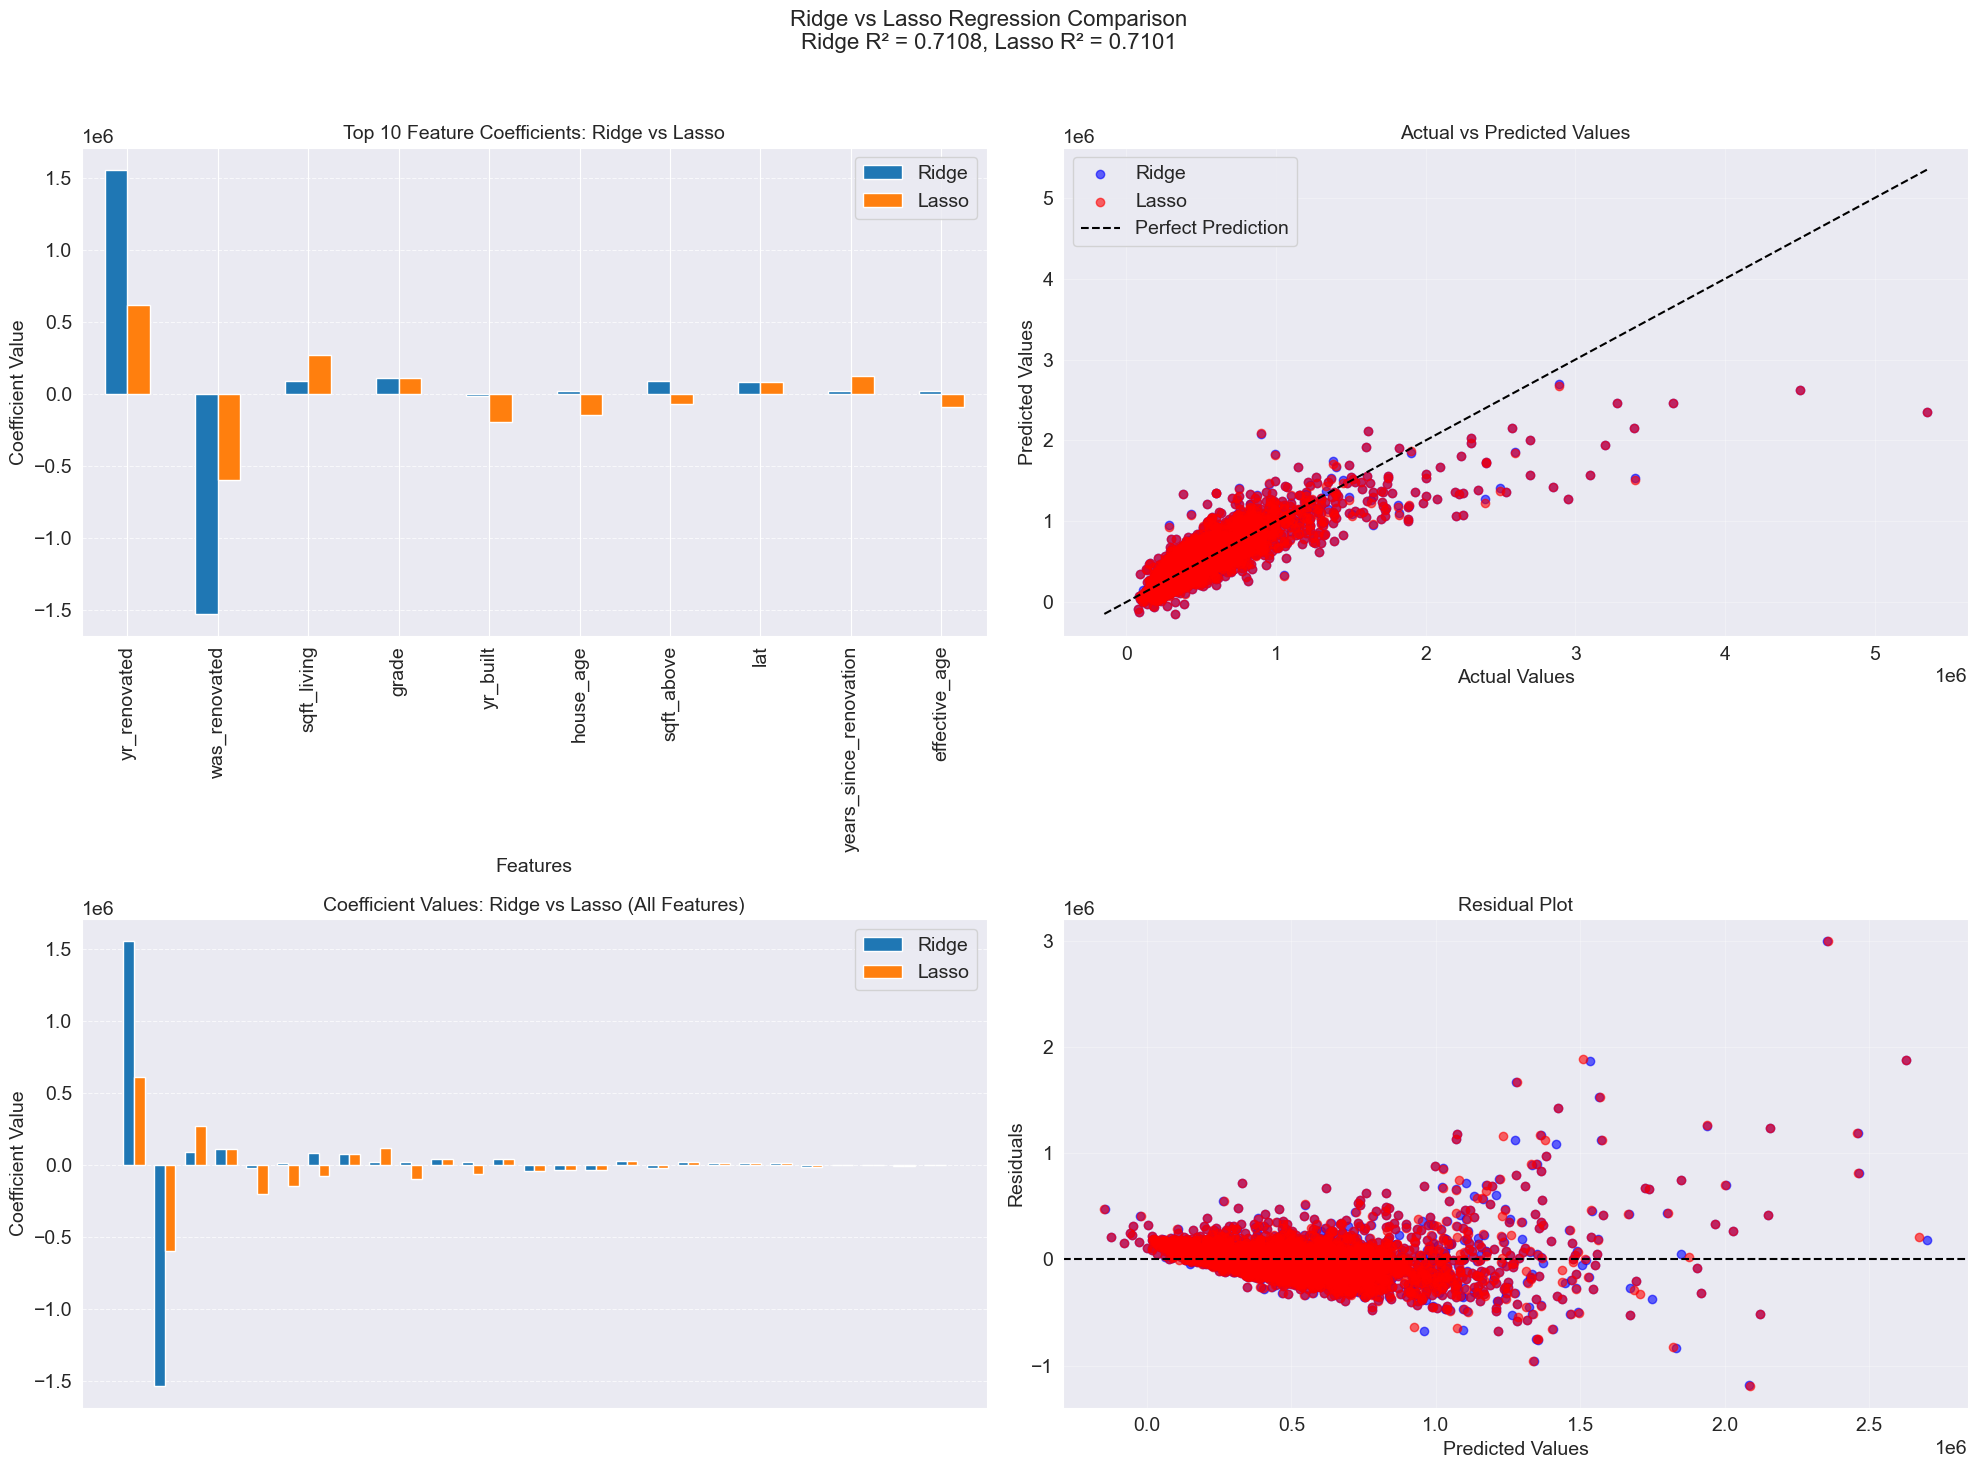

In [104]:
fig = plot_regularization_results(ridge_results, lasso_results, X_val, y_val)
plt.show()

## Development Process

Here’s how I built the project and why I made certain decisions:

### Step 1: Setting Up and Exploring the Dataset

 I imported libraries, loaded the dataset, and used info(), describe(), and value_counts() to understand its structure.

 EDA was essential to identify feature types (e.g., date as object, zipcode as int) and plan preprocessing. No missing values simplified my workflow.


### Step 2: Visualizing Features

I plotted histograms for categorical features and scatterplots for continuous features.

Visualizations revealed distributions and relationships with price, guiding feature engineering (e.g., log-transforming sqft_lot to address skewness).


### Step 3: Feature Engineering

I created lot_living_ratio, log_sqft_lot, house_age, years_since_renovation, was_renovated, and effective_age.

I wanted to capture domain knowledge (e.g., renovation status, house age) and non-linear patterns (e.g., log transformation). Correlations helped validate these features, though some had weaker impacts than expected.

### Step 4: Handling the Date Column

I removed the T000000 suffix, converted date to datetime, and extracted year, month, and day.

The date column’s format was a major hurdle, but resolving it taught me string manipulation and datetime handling. The weak correlations with price were disappointing but justified dropping the original column.

### Step 5: Correlation Analysis

I plotted a correlation heatmap and checked price correlations.

This helped identify key predictors (sqft_living, grade) and multicollinearity (e.g., sqft_living vs. sqft_above), informing my use of Ridge and Lasso.

### Step 6: Preprocessing

I split the data into train/validation/test sets, scaled features, and ensured no leakage.

Splitting first was a best practice to ensure reliable evaluation. Scaling was critical for linear regression and regularization.


### Step 7: Model Training and Evaluation

I trained Linear, Ridge, and Lasso models, evaluating with MSE, RMSE, and R².

Linear Regression was a baseline, while Ridge and Lasso addressed multicollinearity. The similar train and validation metrics showed no overfitting, but the modest R² (~0.71) and high RMSE (~195,000) suggested linear models weren’t capturing all patterns.

### Step 8: Visualizing Results

 I plotted R² scores and coefficient magnitudes.

 Visuals clarified that regularization had minimal impact, motivating my plan to try XGBoost for non-linear modeling.

## Challenges and Solutions

### Challenge 1: Handling the Date Column

Problem: The date column had a T000000 suffix (e.g., 20141013T000000), making it hard to convert to numerical features. It took significant time to figure out how to remove the suffix and extract meaningful features.

Solution: I used str.split('T000000', '') to clean the column, converted it to datetime with pd.to_datetime(), and extracted year, month, and day. This was frustrating but taught me Pandas string manipulation and datetime handling. The low correlations with price were disappointing, but I kept the features for completeness.

### Challenge 2: Multicollinearity


Problem: The heatmap showed high correlations between features like sqft_living, sqft_above, and sqft_basement, and my engineered features (yr_renovated, was_renovated, house_age, effective_age) had large, opposing coefficients, indicating multicollinearity.

Solution: I trained Ridge and Lasso models to handle multicollinearity, expecting Lasso to eliminate redundant features. However, all 27 features were retained, suggesting my features were relevant but possibly redundant. In the future, I’ll use feature selection (e.g., RFE) or try XGBoost, which is robust to multicollinearity.

### Challenge 3: Modest Model Performance

Problem: Despite feature engineering, the R² (~0.71) and RMSE (~195,000) indicated that linear models missed complex patterns in house prices.

Solution: The similar train and validation metrics showed no overfitting, so I focused on model complexity. I plan to use XGBoost to capture non-linear relationships and evaluate on the test set for a final assessment.

## Conclusion

Summary: This project was a deep dive into regression modeling and feature engineering. I successfully explored the King County house sales dataset, engineered features like house_age and was_renovated, resolved the tricky date column issue, and trained Linear, Ridge, and Lasso models. The models achieved a validation R² of ~0.71 and RMSE of ~195,000, with no overfitting (train-validation R² difference: -0.0042). However, the modest R² and high RMSE suggested linear models weren’t fully capturing price variations, likely due to non-linear relationships and multicollinearity.

Lessons Learned: The date column challenge taught me persistence and Pandas string manipulation. Feature engineering was rewarding but showed that not all features (e.g., lot_living_ratio) were as impactful as hoped. Multicollinearity was a key issue, and regularization helped but didn’t solve everything. Visualizations clarified model limitations, pushing me toward non-linear models like XGBoost.

Future Improvements: I plan to train an XGBoost model to capture non-linear patterns, which could improve R² and reduce RMSE. I’ll evaluate on the test set for a final performance check. Feature selection (e.g., RFE) or PCA could reduce multicollinearity, and cross-validation would ensure robust metrics. I might also explore encoding zipcode as a categorical feature to capture location effects better.